**0. Import requireed modules**

In [16]:
import numpy as np
import zipfile
import torch
#from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
#Imported Required Modules and Variables
from pathlib import Path
from google.colab import userdata
from sentence_transformers import SentenceTransformer
from collections import defaultdict
import pandas as pd
import re

In [17]:
from google.colab import drive
drive.mount('/content/drive')
ZIP_FILE = "/content/drive/MyDrive/JavaFiles/capacity.zip"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**1. Provide the path of java files and load their source code into a list**

In [18]:
SOURCE_CODE_DIR = Path("/content/JFiles")
SOURCE_CODE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR = Path("/content/output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_FILE, 'r') as zip_ref:
    zip_ref.extractall(SOURCE_CODE_DIR)

In [19]:
files_list = []
java_files = []
fully_qualified_names = []

java_paths = sorted(SOURCE_CODE_DIR.rglob("*.java"))

for file_path in java_paths:
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            source_code = f.read()

        files_list.append(source_code)

        java_files.append(
    str(
        file_path.relative_to(
            SOURCE_CODE_DIR
        )
    )
)

        # Extract package declaration
        match = re.search(r'package\s+([\w\.]+)\s*;', source_code)

        if match:
            fq_name = f"{match.group(1)}.{file_path.stem}"
        else:
            fq_name = file_path.stem

        fully_qualified_names.append(fq_name)

    except UnicodeDecodeError:
        print("Encoding error:", file_path)

**2. Retrieve the Hugging Face token securely from Colab's "Secrets" tab (the key icon on the left).**

In [20]:
try:
    hf_token = userdata.get('HF_TOKEN')
except userdata.SecretNotFoundError:
    print("WARNING: 'HF_TOKEN' not found in Colab Secrets.")
    hf_token = None

[link text](https://)**3. Hardware optimization (Quantization) NOT REQUIRED FOR CodeRankEmbed**

In [21]:
'''bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, # What is loaded in 4 bit? why?
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)'''

'bnb_config = BitsAndBytesConfig(\n    load_in_4bit=True, # What is loaded in 4 bit? why?\n    bnb_4bit_compute_dtype=torch.float16,\n    bnb_4bit_use_double_quant=True,\n    bnb_4bit_quant_type="nf4"\n)'

**4. Generate embeddings**

In [22]:
embedding_model_name = "nomic-ai/CodeRankEmbed"

In [23]:
#tokenizer = AutoTokenizer.from_pretrained(embedding_model_name,token=hf_token,trust_remote_code=True)
model = SentenceTransformer(embedding_model_name,token=hf_token,trust_remote_code=True)
#model = AutoModel.from_pretrained(embedding_model_name,token=hf_token,quantization_config=bnb_config)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'NomicBertModel'})
  (1): Pooling({'embedding_dimension': 768, 'pooling_mode': 'cls', 'include_prompt': True})
)

In [24]:
MAX_TOKENS = 1024

def embed_source_code(code_files):
    file_embeddings = []

    for code in code_files:

        # tokenize once
        tokens = model.tokenizer.encode(
            code,
            add_special_tokens=False
        )

        # split into chunks
        chunks = []

        for i in range(0, len(tokens), MAX_TOKENS):
            chunk_tokens = tokens[i:i + MAX_TOKENS]

            chunk_text = model.tokenizer.decode(
                chunk_tokens,
                skip_special_tokens=True
            )

            chunks.append(chunk_text)

        # embed all chunks
        chunk_embeddings = model.encode(
            chunks,
            batch_size=4,
            convert_to_numpy=True,
            show_progress_bar=False
        )

        # average chunk embeddings -> one vector per file
        file_embedding = np.mean(chunk_embeddings, axis=0)

        file_embeddings.append(file_embedding)

    return np.array(file_embeddings)


**5. Construct the semantic similarity matrix**

In [25]:
embeddings = embed_source_code(files_list)
semantic_matrix = cosine_similarity(embeddings)

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (14940 > 8192). Running this sequence through the model will result in indexing errors


**6. Construct the structural similarity matrix**

In [26]:
# scan the filtered .rsf dependency file from week 1 to construct a matrix where each entry is the number of packages each pair of files depend on.
# executing this cell produces 'struct_matrix_raw'

# Path to your filtered RSF file
RSF_FILE = "/content/JFiles/capacity/filtered_rsf.rsf"

# Build dependency map: file -> set of dependent packages
dependency_map = defaultdict(set)

with open(RSF_FILE, "r") as f:
    for line in f:
        parts = line.strip().split()

        if len(parts) >= 3:
            relation, source_file, target_package = parts[:3]
            dependency_map[source_file].add(target_package)


n = len(fully_qualified_names)

# Structural similarity matrix
struct_matrix_raw = np.zeros((n, n))

for i in range(n):
    deps_i = dependency_map.get(fully_qualified_names[i], set())

    for j in range(n):
        deps_j = dependency_map.get(fully_qualified_names[j], set())

        # Number of common dependencies
        overlap = len(deps_i.intersection(deps_j))

        struct_matrix_raw[i, j] = overlap

print("Structural matrix shape:", struct_matrix_raw.shape)
print("Max overlap:", struct_matrix_raw.max())
print("Non-zero entries:", np.count_nonzero(struct_matrix_raw))
print("Example Java class:", fully_qualified_names[0])
print("Exists in dependency map:",
      fully_qualified_names[0] in dependency_map)

print("Number of classes in dependency map:", len(dependency_map))

Structural matrix shape: (101, 101)
Max overlap: 162.0
Non-zero entries: 4373
Example Java class: org.apache.hadoop.yarn.server.resourcemanager.scheduler.capacity.AbsoluteResourceCapacityCalculator
Exists in dependency map: True
Number of classes in dependency map: 226


**7. Normalize the structural matrix**

In [27]:
max_overlap = struct_matrix_raw.max()
struct_matrix = struct_matrix_raw / max_overlap if max_overlap > 0 else struct_matrix_raw
np.fill_diagonal(struct_matrix, 1.0)

**8. Combine the two matrices into one similarity matrix then apply complement.**

In [28]:
# ALPHA dictates the weight of structural vs. semantic data.
# E.g., 0.4 means 40% Structural (RSF) and 60% Semantic (CodeBERT)
ALPHA = 0.6
combined_similarity = (ALPHA * struct_matrix) + ((1 - ALPHA) * semantic_matrix)

# Invert similarity to get distance
distance_matrix = 1.0 - combined_similarity
np.fill_diagonal(distance_matrix, 0)

**9. Apply clustering**

In [ ]:
TARGET_NUM_CLUSTERS = 20 # how such parameter could be optimized?
clusterer = AgglomerativeClustering(n_clusters=TARGET_NUM_CLUSTERS, metric='precomputed', linkage='complete') # what is 'precomputed' & 'linkage'?
clusters = clusterer.fit_predict(distance_matrix)

results = pd.DataFrame({
    "Entity": fully_qualified_names,
    "Cluster": clusters
})

print(results)

rsf_output = OUTPUT_DIR / "ARC_Clusters.rsf"

cluster_assignments = sorted(
    zip(clusters, fully_qualified_names),
    key=lambda x: (x[0], x[1])
)

with open(rsf_output, "w") as f:
    previous_cluster = None

    for cluster_id, entity_name in cluster_assignments:

        f.write(f"contain {cluster_id} {entity_name}\n")
        previous_cluster = cluster_id

print(f"RSF file written to: {rsf_output}")

print("Example Java class:", fully_qualified_names[0])
print("Exists in dependency map:",
      fully_qualified_names[0] in dependency_map)

                                                Entity  Cluster
0    org.apache.hadoop.yarn.server.resourcemanager....        0
1    org.apache.hadoop.yarn.server.resourcemanager....       14
2    org.apache.hadoop.yarn.server.resourcemanager....       14
3    org.apache.hadoop.yarn.server.resourcemanager....       14
4    org.apache.hadoop.yarn.server.resourcemanager....        1
..                                                 ...      ...
96   org.apache.hadoop.yarn.server.resourcemanager....       11
97   org.apache.hadoop.yarn.server.resourcemanager....        1
98              GuaranteedOrZeroCapacityOverTimePolicy        1
99   org.apache.hadoop.yarn.server.resourcemanager....        1
100  org.apache.hadoop.yarn.server.resourcemanager....       16

[101 rows x 2 columns]
RSF file written to: /content/output/cluster_assignments.rsf
Example Java class: org.apache.hadoop.yarn.server.resourcemanager.scheduler.capacity.AbsoluteResourceCapacityCalculator
Exists in dependency map: T

**10. Visulizations**

/tmp/ipykernel_14308/3822311274.py:6: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(distance_matrix, method='complete')


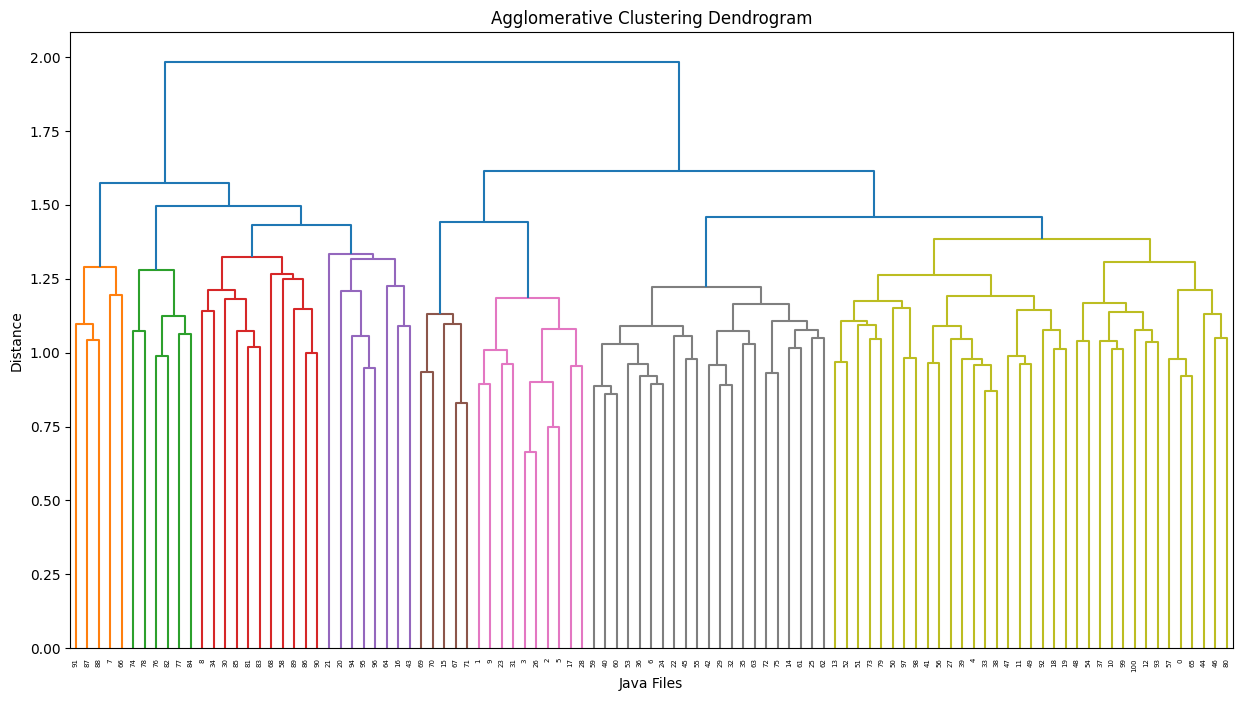

In [30]:
# According to the applied algorithm documentation, provide any visualizations for better understanding of how the clusters are formed.
#Dendogram
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

Z = linkage(distance_matrix, method='complete')

plt.figure(figsize=(15, 8))
dendrogram(Z)
plt.title("Agglomerative Clustering Dendrogram")
plt.xlabel("Java Files")
plt.ylabel("Distance")
plt.show()
